NDBC historical stdmet downloader
Parquet saving, and histogram QC plots.

Created on Sun Jan 25 2026

Enter Station Number (letters lowercase if any):  46086


… 46086 2026: missing/unreadable (streak 1)
… 46086 2025: missing/unreadable (streak 2)
✅ 46086 2024: 16858 rows
✅ 46086 2023: 17421 rows
✅ 46086 2022: 10892 rows
✅ 46086 2021: 6923 rows
✅ 46086 2020: 2177 rows
✅ 46086 2019: 8643 rows
✅ 46086 2018: 8717 rows
✅ 46086 2017: 8667 rows
✅ 46086 2016: 8721 rows
✅ 46086 2015: 8727 rows
✅ 46086 2014: 8737 rows
✅ 46086 2013: 8718 rows
✅ 46086 2012: 8082 rows
✅ 46086 2011: 8630 rows
✅ 46086 2010: 8462 rows
✅ 46086 2009: 2844 rows
✅ 46086 2008: 3375 rows
✅ 46086 2007: 7784 rows
✅ 46086 2006: 8659 rows
✅ 46086 2005: 8656 rows
✅ 46086 2004: 8717 rows
✅ 46086 2003: 1322 rows
… 46086 2002: missing/unreadable (streak 1)
… 46086 2001: missing/unreadable (streak 2)
… 46086 2000: missing/unreadable (streak 3)
… 46086 1999: missing/unreadable (streak 4)
… 46086 1998: missing/unreadable (streak 5)


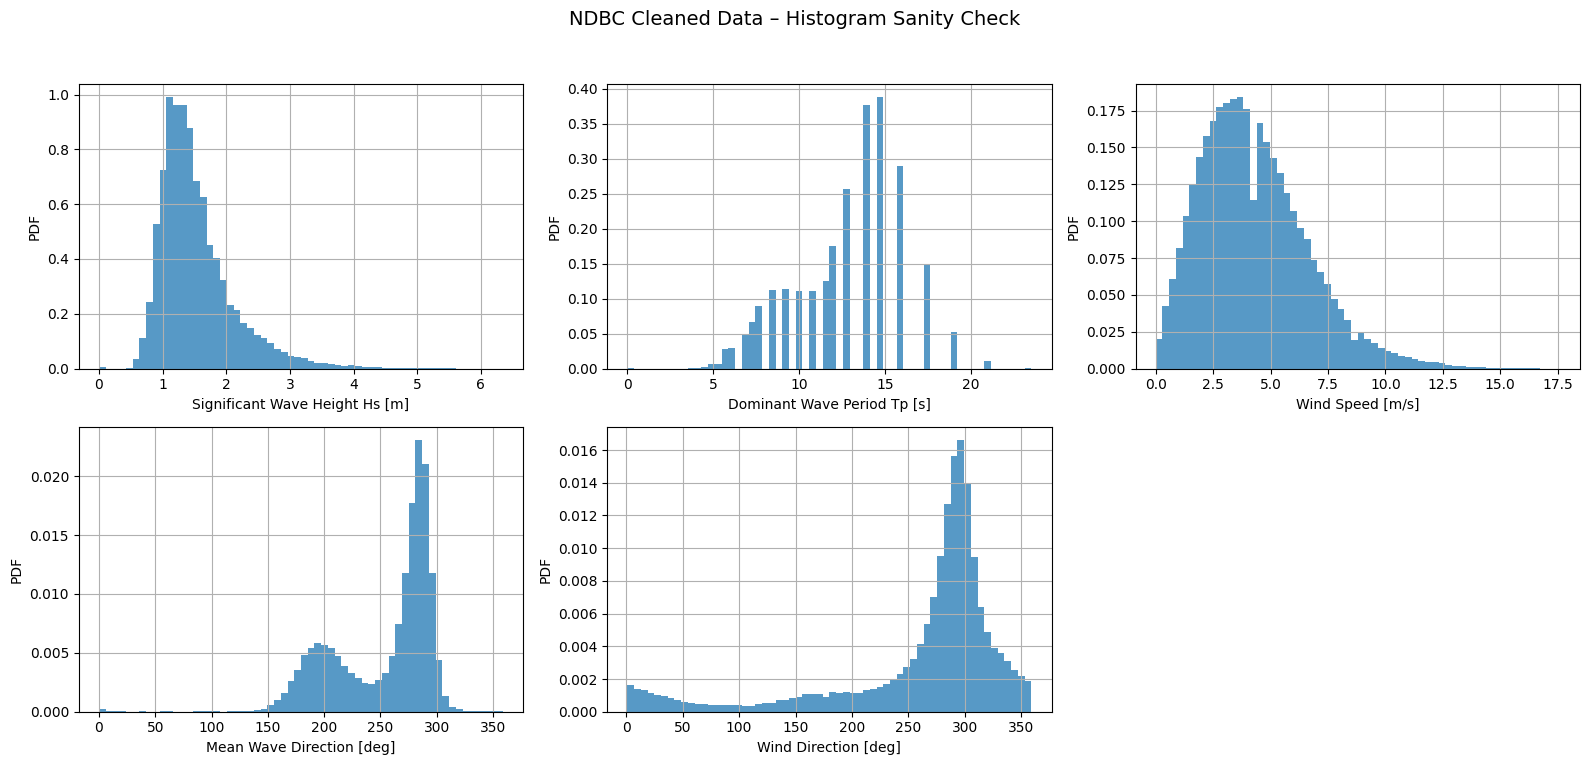


Downloaded & saved cleaned data for years: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
             datetime  WVHT  DPD  MWD  WDIR  WSPD
0 2003-11-06 00:00:00   0.0  0.0    0   246   1.1
1 2003-11-06 01:00:00   0.0  0.0    0   266   2.6
2 2003-11-06 02:00:00   0.0  0.0    0   273   0.7
3 2003-11-06 03:00:00   0.0  0.0    0   252   0.2
4 2003-11-06 04:00:00   0.0  0.0    0   335   0.7


In [2]:
import io
import gzip
import pandas as pd
import requests
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, List, Tuple


FRONT = "https://www.ndbc.noaa.gov/view_text_file.php?filename="
LAST  = ".txt.gz&dir=data/historical/stdmet/"


def build_url(station: str, year: int) -> str:
    station = station.strip()
    return f"{FRONT}{station}h{year}{LAST}"
def clean_ndbc_directional_data(dat: pd.DataFrame) -> pd.DataFrame:
    """
    Remove NDBC missing-value flags and non-physical values
    for directional variables.
    """
    # Wind direction
    if "WDIR" in dat.columns:
        dat = dat[(dat["WDIR"] >= 0) & (dat["WDIR"] < 360)]

    # Mean wave direction
    if "MWD" in dat.columns:
        dat = dat[(dat["MWD"] >= 0) & (dat["MWD"] < 360)]

    return dat


def fetch_ndbc_text(url: str, timeout: int = 60) -> Optional[str]:
    """
    Robust fetcher for NDBC 'view_text_file.php' responses.

    NDBC sometimes serves:
      (A) gzipped bytes (true .gz)
      (B) already-plain text (starts with '#YY' / '#YYYY')
      (C) HTML error pages

    Returns:
      - decompressed/decoded text on success
      - None if 404 / empty / HTML error page
    """
    r = requests.get(url, timeout=timeout)
    if r.status_code == 404:
        return None
    r.raise_for_status()
    if not r.content:
        return None

    raw = r.content

    # Case A: gzipped payload (gzip magic bytes: 1F 8B)
    if len(raw) >= 2 and raw[0] == 0x1F and raw[1] == 0x8B:
        with gzip.GzipFile(fileobj=io.BytesIO(raw)) as gz:
            return gz.read().decode("utf-8", errors="replace")

    # Case B/C: plain text or HTML
    txt = raw.decode("utf-8", errors="replace")
    head = txt.lstrip()[:200].lower()
    if "<html" in head or "<!doctype" in head:
        return None

    return txt


def read_ndbc_year_like_yours(text: str, year: int) -> pd.DataFrame:
    """
    Parse one year of NDBC stdmet data using the SAME branching/formatting logic
    as your original script.

    Returns columns (same as your dat_sum build):
      datetime, WVHT, DPD, MWD, WDIR, WSPD
    """
    buf = io.StringIO(text)

    if year < 1999:
        data = pd.read_csv(buf, sep=r"\s+", engine="python", skiprows=0)

        # YY -> 4-digit year (your rule)
        data["YY"] = data["YY"].apply(lambda x: "19" + str(x) if x > 50 else "20" + str(x))
        data["mm"] = 0

        data["datetime"] = pd.to_datetime(
            data[["YY", "MM", "DD", "hh", "mm"]].astype(str).agg("-".join, axis=1),
            format="%Y-%m-%d-%H-%M",
        )

        # Cleaning like yours
        data = data[data["WSPD"] != 99.0]
        data = data[data["WVHT"] != 99.0]
        data = data[data["DPD"] != 99.0]

        WDIR = data["WD"]
        WSPD = data["WSPD"]
        WVHT = data["WVHT"]
        DPD  = data["DPD"]
        MWD  = data["MWD"]
        DateTime = data["datetime"]

    elif year < 2005:
        data = pd.read_csv(buf, sep=r"\s+", engine="python", skiprows=0)

        data["mm"] = 0
        data["datetime"] = pd.to_datetime(
            data[["YYYY", "MM", "DD", "hh", "mm"]].astype(str).agg("-".join, axis=1),
            format="%Y-%m-%d-%H-%M",
        )

        data = data[data["WSPD"] != 99.0]
        data = data[data["WVHT"] != 99.0]
        data = data[data["DPD"] != 99.0]

        WDIR = data["WD"]
        WSPD = data["WSPD"]
        WVHT = data["WVHT"]
        DPD  = data["DPD"]
        MWD  = data["MWD"]
        DateTime = data["datetime"]

    elif year < 2007:
        data = pd.read_csv(buf, sep=r"\s+", engine="python", skiprows=0)

        data["datetime"] = pd.to_datetime(
            data[["YYYY", "MM", "DD", "hh", "mm"]].astype(str).agg("-".join, axis=1),
            format="%Y-%m-%d-%H-%M",
        )

        data = data[data["WSPD"] != 99.0]
        data = data[data["WVHT"] != 99.0]
        data = data[data["DPD"] != 99.0]

        WDIR = data["WD"]
        WSPD = data["WSPD"]
        WVHT = data["WVHT"]
        DPD  = data["DPD"]
        MWD  = data["MWD"]
        DateTime = data["datetime"]

    else:
        # Your code: skip the 2nd row (index 1) and use #YY for year col
        buf.seek(0)
        data = pd.read_csv(buf, sep=r"\s+", engine="python", skiprows=[1])

        data["datetime"] = pd.to_datetime(
            data[["#YY", "MM", "DD", "hh", "mm"]].astype(str).agg("-".join, axis=1),
            format="%Y-%m-%d-%H-%M",
        )

        data = data[data["WSPD"] != 99.0]
        data = data[data["WVHT"] != 99.0]
        data = data[data["DPD"] != 99.0]

        WDIR = data["WDIR"]
        WSPD = data["WSPD"]
        WVHT = data["WVHT"]
        DPD  = data["DPD"]
        MWD  = data["MWD"]
        DateTime = data["datetime"]

    dat = pd.concat([DateTime, WVHT, DPD, MWD, WDIR, WSPD], axis=1)
    dat.columns = ["datetime", "WVHT", "DPD", "MWD", "WDIR", "WSPD"]
    return dat


def plot_ndbc_histograms(df: pd.DataFrame, bins: int = 60) -> None:
    """
    Visual QC check: histograms of WVHT, DPD, WSPD, MWD, WDIR.
    """
    fig, axs = plt.subplots(2, 3, figsize=(16, 8))
    axs = axs.flatten()

    plots = [
        ("WVHT", "Significant Wave Height Hs [m]"),
        ("DPD",  "Dominant Wave Period Tp [s]"),
        ("WSPD", "Wind Speed [m/s]"),
        ("MWD",  "Mean Wave Direction [deg]"),
        ("WDIR", "Wind Direction [deg]"),
    ]

    for ax, (col, label) in zip(axs, plots):
        ax.hist(df[col].dropna(), bins=bins, density=True, alpha=0.75)
        ax.set_xlabel(label)
        ax.set_ylabel("PDF")
        ax.grid(True)

    axs[-1].axis("off")
    plt.suptitle("NDBC Cleaned Data – Histogram Sanity Check", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def download_ndbc_station_backwards_clean_and_save(
    station: str,
    out_dir: str = "./ndbc_parquet",
    start_year: Optional[int] = None,
    end_year: Optional[int] = None,
    stop_after_missing: int = 5,
    max_retries_per_year: int = 10,
    timeout: int = 60,
    save_combined: bool = True,
    print_progress: bool = True,
) -> Tuple[pd.DataFrame, List[int]]:
    """
    Start from current year and go backward, using YOUR formatting + cleaning,
    then save Parquet.

    Notes:
      - stop_after_missing default bumped to 5 because current year is often missing as a historical file.
    """
    if start_year is None:
        start_year = pd.Timestamp.utcnow().year

    station = station.strip()
    out_path = Path(out_dir) / station
    out_path.mkdir(parents=True, exist_ok=True)

    dat_sum = pd.DataFrame()
    years_ok: List[int] = []
    missing_streak = 0

    year = start_year
    last_err = None

    while True:
        if end_year is not None and year < end_year:
            break

        url = build_url(station, year)

        success = False
        for attempt in range(max_retries_per_year):
            try:
                text = fetch_ndbc_text(url, timeout=timeout)
                if text is None:
                    break  # missing year (404/empty/HTML)

                dat = read_ndbc_year_like_yours(text, year)
                dat = clean_ndbc_directional_data(dat)


                dat_sum = pd.concat([dat_sum, dat], ignore_index=True)
                years_ok.append(year)

                # Save per-year cleaned Parquet
                dat_sorted = dat.sort_values("datetime").drop_duplicates(subset=["datetime"])
                dat_sorted.to_parquet(out_path / f"{station}_stdmet_clean_{year}.parquet", index=False)

                if print_progress:
                    print(f"✅ {station} {year}: {len(dat_sorted)} rows")

                success = True
                break

            except Exception as e:
                last_err = e
                if attempt == max_retries_per_year - 1:
                    if print_progress:
                        print(f"❌ {station} {year}: failed after retries. Last error: {e}")

        if not success:
            missing_streak += 1
            if print_progress:
                print(f"… {station} {year}: missing/unreadable (streak {missing_streak})")
            if missing_streak >= stop_after_missing:
                break
        else:
            missing_streak = 0

        year -= 1

    if dat_sum.empty:
        raise RuntimeError(
            f"No data downloaded for station {station} starting from {start_year}. "
            f"Last error: {last_err}"
        )

    # Final sort + dedupe before saving combined
    dat_sum = (
        dat_sum.sort_values("datetime")
        .drop_duplicates(subset=["datetime"])
        .reset_index(drop=True)
    )

    if save_combined:
        dat_sum.to_parquet(out_path / f"{station}_stdmet_clean_all_years.parquet", index=False)

    return dat_sum, sorted(years_ok)


if __name__ == "__main__":
    buoy = input("Enter Station Number (letters lowercase if any): ").strip()

    df, years = download_ndbc_station_backwards_clean_and_save(
        station=buoy,
        out_dir="./ndbc_parquet",
        start_year=None,   # current year
        end_year=None,     # stop based on missing streak
        stop_after_missing=5,
        max_retries_per_year=10,
        save_combined=True,
        print_progress=True,
    )

    plot_ndbc_histograms(df)
    print(f"\nDownloaded & saved cleaned data for years: {years}")
    print(df.head())
